# Exercice 1.4 bis : Détection d’anomalies — contexte « localisation »

On cherche des ventes **atypiques** : prix extrême par rapport au quartier, ou combinaisons rares localisation / prix. Même plan méthodologique que E4, adapté à `df_loc`.


## Section 1.1 — Préparation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from scipy import stats

df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(" ", "")
COLS_LOC = ["Neighborhood", "MSZoning", "Condition1", "Condition2", "SalePrice"]
df_loc = df[COLS_LOC].dropna().copy()

le_n = LabelEncoder()
df_loc["Neighborhood_code"] = le_n.fit_transform(df_loc["Neighborhood"])


## Section 1.2 — IQR et z-score modifié sur `SalePrice`


In [2]:
s = df_loc["SalePrice"]
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

med = s.median()
mad = stats.median_abs_deviation(s, scale="normal")
z = 0.6745 * (s - med) / mad
mask_z = np.abs(z) > 3.5
df_loc["flag_iqr"] = mask_iqr
df_loc["flag_z"] = mask_z
print("IQR outliers :", mask_iqr.sum(), "| z-mod outliers :", mask_z.sum())


IQR outliers : 97 | z-mod outliers : 22


## Section 1.3 — Isolation Forest (prix + code quartier)


In [4]:
X_if = df_loc[["SalePrice", "Neighborhood_code"]].values
iso = IsolationForest(random_state=42, contamination=0.05)
pred_iso = iso.fit_predict(X_if)
df_loc["iso"] = pred_iso
print("Anomalies IF :", (pred_iso == -1).sum())


Anomalies IF : 110


## Section 1.4 — DBSCAN (features normalisées)


In [5]:
sc = StandardScaler()
X_db = sc.fit_transform(df_loc[["SalePrice", "Neighborhood_code"]])
db = DBSCAN(eps=0.5, min_samples=10)
df_loc["dbscan"] = db.fit_predict(X_db)
print("Clusters / bruit DBSCAN :", np.unique(df_loc["dbscan"], return_counts=True))


Clusters / bruit DBSCAN : (array([-1,  0]), array([  20, 2177]))


## Section 1.5 — Tableau comparatif et scatter


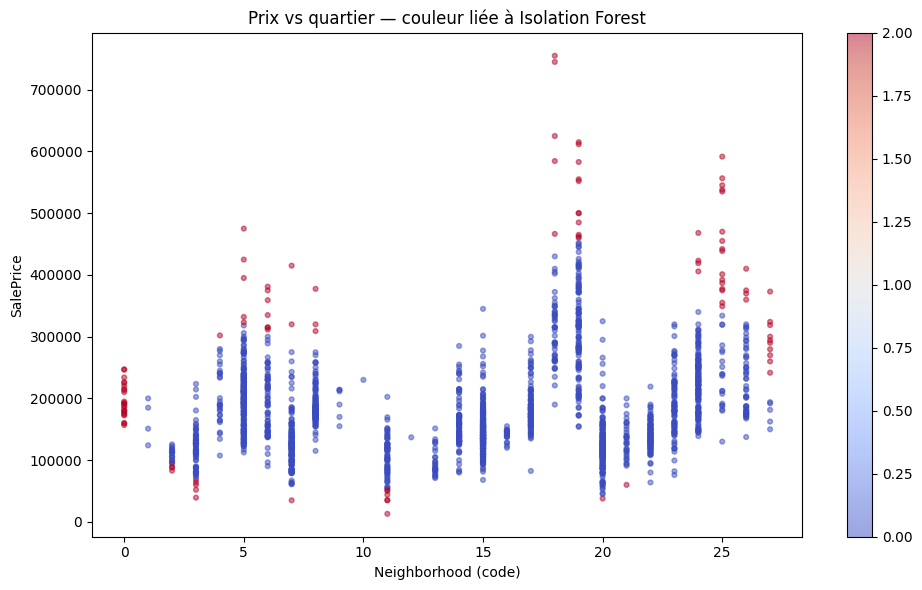

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sca = ax.scatter(
    df_loc["Neighborhood_code"],
    df_loc["SalePrice"],
    c=np.where(df_loc["iso"] == -1, 2, 0),
    cmap="coolwarm",
    alpha=0.5,
    s=12,
)
ax.set_xlabel("Neighborhood (code)")
ax.set_ylabel("SalePrice")
ax.set_title("Prix vs quartier — couleur liée à Isolation Forest")
plt.colorbar(sca, ax=ax)
plt.tight_layout()
plt.show()


## Section 2: LOF (optionnel)


In [7]:
try:
    from sklearn.neighbors import LocalOutlierFactor

    X_lof = StandardScaler().fit_transform(df_loc[["SalePrice", "Neighborhood_code"]])
    lof = LocalOutlierFactor(n_neighbors=30, contamination=0.05)
    df_loc["lof"] = lof.fit_predict(X_lof)
    print("LOF outliers :", (df_loc["lof"] == -1).sum())
except Exception as e:
    print(e)


LOF outliers : 110


## Section 3: Stratégies (Markdown à compléter)


- Liste d’actions possibles : garder, investiguer, caper le prix, segmenter par quartier.
- Log-transform du prix pour réduire l’asymétrie avant clustering.


## Section 4: Great Expectations (optionnel)


Si vous utilisez GX : attentes sur `SalePrice` > 0, modalités connues pour `Neighborhood`, etc.


## Section 5: Bilan critique


Un prix « anormal » peut être une **erreur** ou une **vente atypique légitime** (très grande maison dans un quartier modeste) : la localisation seule n’explique pas tout.
